#### **Problem Statement :**
##### You have tasked with creating a dicision tree model to predict whther a person is likely to purchase a new smartphone based on their age , income and education level. You are provided with a dataset containing these attributes and the target variable indicating whether the person made a purchase or not.

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0
            User ID         Age  EstimatedSalary   Purchased
count  4.000000e+02  400.000000       400.000000  400.000000
mean   1.569154e+07   37.655000     69742.500000    0.357500
std    7.165832e+04   10.482877     34096.960282    0.479864
min    1.556669e+07   18.000000     15000.000000    0.000000
25%    1.562676e+07   29.750000     43000.000000    0.000000
50%    1.569434e+07   37.000000     70000.000000    0.000000
75%    1.575036e+07   46.000000     88000.000000    1.000000
max    1.581524e+07   60.000000    150000.000000    1.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Nul

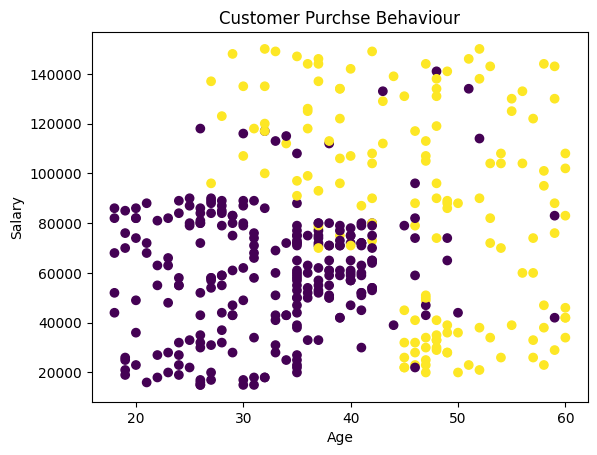


Accuracy :  0.9125

Confusion Matrix : 
 [[47  5]
 [ 2 26]]


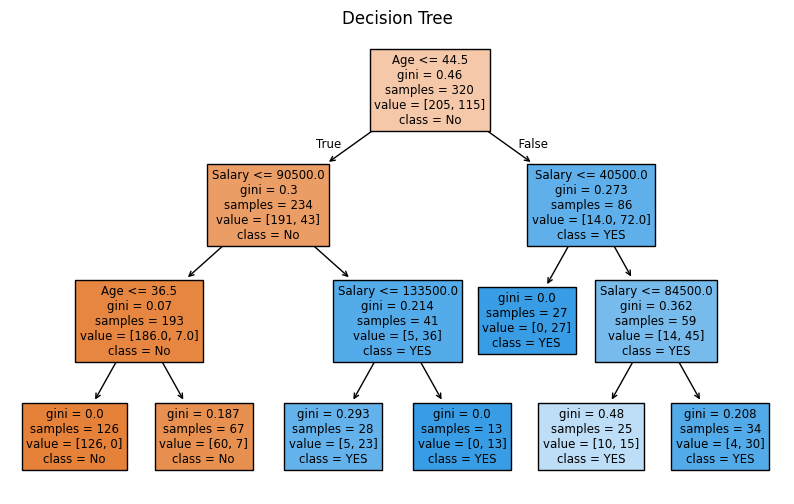


 Not Target Customer (Will Not Purchse)


C:\Users\sagar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [12]:
# Step NO : 1
# importing the necessary Libraries 
import pandas as pd  # for handling data
import numpy as np   # for numerical operation
from sklearn.model_selection import train_test_split # to split data into train & test 
from sklearn.preprocessing import StandardScaler # for feature scaling 
from sklearn.tree import DecisionTreeClassifier  # Decision tree model 
from sklearn.metrics import accuracy_score , confusion_matrix # evalution 
# Import plot_tree function to visualize the trained Decision Tree model
from sklearn.tree import plot_tree

# Step 2 : 
# Uploading  the dataset 
df = pd.read_csv("Social_Network_Ads.csv")
df.to_string

# Step No : 3  Understanding the dataset 
# Display the first few rows of the dataset 
print(df.head())
# Statistical summary of the dataset 
print(df.describe())
# check column names and data types 
print(df.info())

# Step 4 : Data Cleaning and Preprocessing 
# Check for missing values 
print(df.isnull().sum())
# Check for duplicate values 
print(df.duplicated().sum())

# Step 5 : features and Target Splitting
X = df[["Age" , "EstimatedSalary"]]
y = df[["Purchased"]]

# Step 6 : Visualization  
import matplotlib.pyplot as  plt 
# Scatter Plot of Age VS EstimatedSalary by Purchased 
plt.scatter(df["Age"] , df["EstimatedSalary"] , c = df["Purchased"])
plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Customer Purchse Behaviour")
plt.savefig("images/scatter_plot.png")
plt.show()

# Step 7 : Train Test Split for model evaluation
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42)

# Step 8  : Intialize the model 
model = DecisionTreeClassifier(criterion= "gini" , max_depth=3)

# Step 9 : Train the model 
model.fit(X_train , y_train)

# Step NO 10 : Model Prediction 
y_pred = model.predict(X_test)

# Step No 11 : Model Evaluation 
accuracy = accuracy_score(y_test , y_pred)
print("\nAccuracy : ", accuracy)

cm = confusion_matrix(y_test , y_pred)
print("\nConfusion Matrix : \n", cm)

#  Step No 12 : Decision Tree Visualization 
plt.figure(figsize=(10,6))
plot_tree(model , feature_names = ["Age" , "Salary"] , class_names = ["No" , "YES"] , filled = True)
plt.title("Decision Tree")
plt.savefig("images/decision_tree.png")
plt.show()

# Step No 13 : User Input 
age = int(input("\nEnter Age : "))
salary = int(input("Enter Salary : "))

# Step No 14 :  Prediction on your user input 
user_data = np.array([[age , salary]])
result = model.predict(user_data)

# Step No 15 : Output Result 
if result[0] == 1:
    print("\n Target Customer (Will Purchase )")
else: 
    print("\n Not Target Customer (Will Not Purchse)")

### **Conclusion :**

The Decision Tree model successfully predicts customer purchase behavior with high accuracy.
It is simple, interpretable, and effective for classification tasks.